# Pertemuan 7: K-Means Clustering dan Hierarchical Clustering

## Identitas Mahasiswa

**Nama:** MUH. ALI IMRAN  
**NIM:** 105841113523  
**Program Studi:** Informatika  
**Mata Kuliah:** Applied Machine Learning

## Tujuan

1. Memahami konsep unsupervised learning dan clustering.
2. Mengimplementasikan K-Means Clustering.
3. Menentukan jumlah cluster optimal.
4. Mengimplementasikan Hierarchical Clustering.
5. Membuat dan menginterpretasi dendrogram.
6. Melakukan customer segmentation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.datasets import make_blobs, load_iris

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Library berhasil diimport.")

Library berhasil diimport.


In [2]:
# ============================================
# TUGAS 1 - K-MEANS CLUSTERING
# ============================================

iris = load_iris()

iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

iris_df["target"] = iris.target
iris_df["target_name"] = [
    iris.target_names[i] for i in iris.target
]

print("=== Informasi Dataset Iris ===")
print("Jumlah data :", iris_df.shape[0])
print("Jumlah fitur:", len(iris.feature_names))

print("\nNama fitur:")
print(iris.feature_names)

print("\nDistribusi kelas:")
print(iris_df["target_name"].value_counts())

display(iris_df.head())

=== Informasi Dataset Iris ===
Jumlah data : 150
Jumlah fitur: 4

Nama fitur:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Distribusi kelas:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
# Memilih 2 fitur untuk visualisasi
# Sepal Length dan Petal Length

X_iris = iris_df[
    ["sepal length (cm)", "petal length (cm)"]
].values

y_iris = iris.target

# Standardisasi data
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

print("Shape data:", X_iris.shape)

print("\nContoh data setelah standardisasi:")
display(
    pd.DataFrame(
        X_iris_scaled,
        columns=["Sepal Length", "Petal Length"]
    ).head()
)

Shape data: (150, 2)

Contoh data setelah standardisasi:


,Sepal Length,Petal Length
0,-0.900681,-1.340227
1,-1.143017,-1.340227
2,-1.385353,-1.397064
3,-1.506521,-1.283389
4,-1.021849,-1.340227


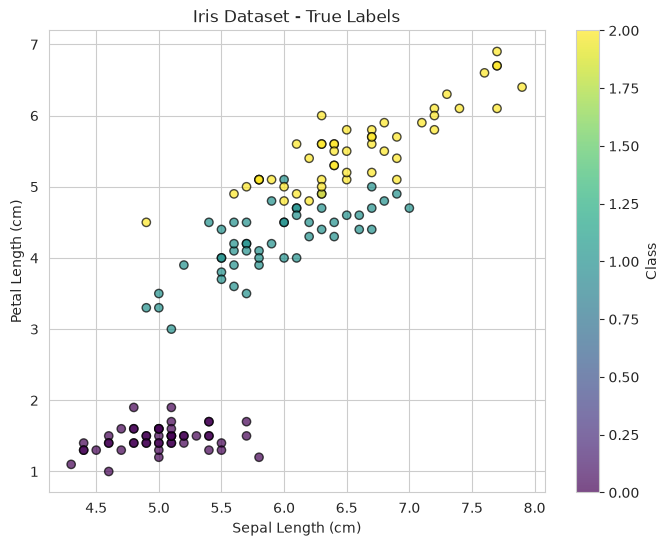

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_iris[:, 0],
    X_iris[:, 1],
    c=y_iris,
    cmap="viridis",
    alpha=0.7,
    edgecolors="k"
)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("Iris Dataset - True Labels")
plt.colorbar(label="Class")

plt.show()

In [5]:
# ============================================
# MENENTUKAN K OPTIMAL
# ============================================

K_range = range(2, 11)

inertias_iris = []
silhouette_scores_iris = []

for k in K_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans_temp.fit_predict(X_iris_scaled)

    inertias_iris.append(kmeans_temp.inertia_)
    silhouette_scores_iris.append(
        silhouette_score(X_iris_scaled, labels)
    )

print("Perhitungan K = 2 sampai 10 selesai.")

Perhitungan K = 2 sampai 10 selesai.


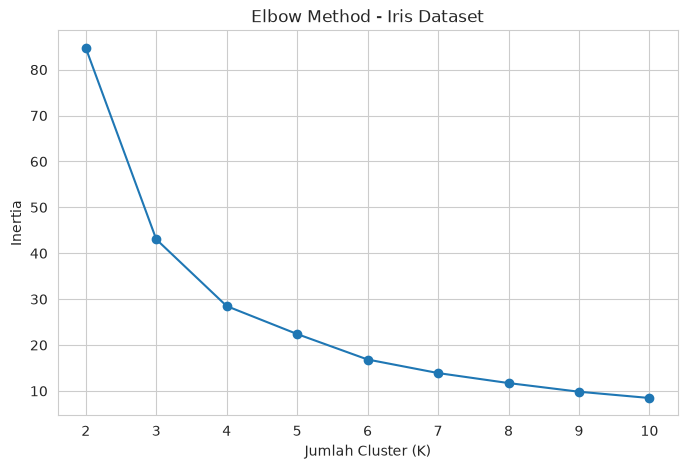

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(K_range),
    inertias_iris,
    marker="o"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Iris Dataset")
plt.xticks(list(K_range))
plt.grid(True)

plt.show()

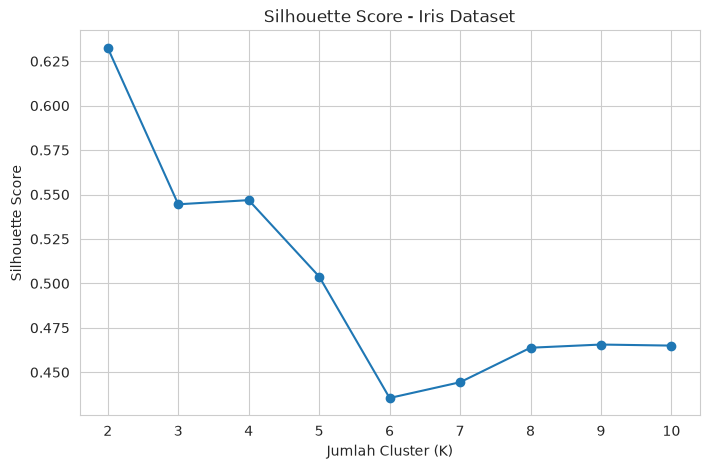

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(K_range),
    silhouette_scores_iris,
    marker="o"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Iris Dataset")
plt.xticks(list(K_range))
plt.grid(True)

plt.show()

In [8]:
# K dengan Silhouette Score tertinggi
optimal_k_iris = list(K_range)[
    np.argmax(silhouette_scores_iris)
]

best_silhouette_iris = max(silhouette_scores_iris)

print("=== HASIL K OPTIMAL ===")
print(f"K optimal berdasarkan Silhouette Score: {optimal_k_iris}")
print(f"Silhouette Score tertinggi: {best_silhouette_iris:.4f}")

print("\nNilai setiap K:")
for k, inertia, sil in zip(
    K_range,
    inertias_iris,
    silhouette_scores_iris
):
    print(
        f"K={k}: Inertia={inertia:.2f}, "
        f"Silhouette={sil:.4f}"
    )

=== HASIL K OPTIMAL ===
K optimal berdasarkan Silhouette Score: 2
Silhouette Score tertinggi: 0.6324

Nilai setiap K:
K=2: Inertia=84.72, Silhouette=0.6324
K=3: Inertia=43.03, Silhouette=0.5445
K=4: Inertia=28.49, Silhouette=0.5468
K=5: Inertia=22.40, Silhouette=0.5038
K=6: Inertia=16.85, Silhouette=0.4355
K=7: Inertia=13.90, Silhouette=0.4444
K=8: Inertia=11.72, Silhouette=0.4638
K=9: Inertia=9.83, Silhouette=0.4656
K=10: Inertia=8.46, Silhouette=0.4650


In [9]:
# ============================================
# K-MEANS FINAL
# ============================================

kmeans_iris = KMeans(
    n_clusters=optimal_k_iris,
    random_state=42,
    n_init=10
)

iris_clusters = kmeans_iris.fit_predict(
    X_iris_scaled
)

print("=== Evaluasi K-Means ===")
print(f"Jumlah cluster : {optimal_k_iris}")
print(f"Inertia        : {kmeans_iris.inertia_:.4f}")
print(
    f"Silhouette     : "
    f"{silhouette_score(X_iris_scaled, iris_clusters):.4f}"
)
print(
    f"Davies-Bouldin : "
    f"{davies_bouldin_score(X_iris_scaled, iris_clusters):.4f}"
)

=== Evaluasi K-Means ===
Jumlah cluster : 2
Inertia        : 84.7207
Silhouette     : 0.6324
Davies-Bouldin : 0.4707


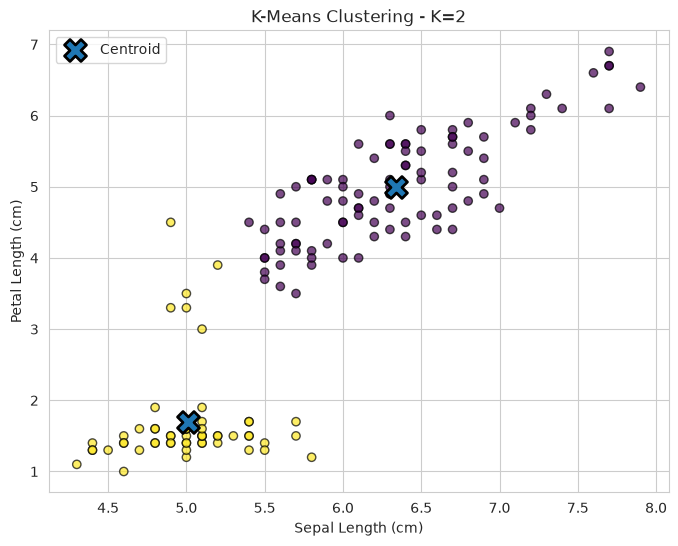

In [10]:
# ============================================
# VISUALISASI HASIL K-MEANS
# ============================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_iris[:, 0],
    X_iris[:, 1],
    c=iris_clusters,
    cmap="viridis",
    alpha=0.7,
    edgecolors="k"
)

# Centroid dikembalikan ke skala asli
centers_original = scaler_iris.inverse_transform(
    kmeans_iris.cluster_centers_
)

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker="X",
    s=250,
    edgecolors="black",
    linewidths=2,
    label="Centroid"
)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title(f"K-Means Clustering - K={optimal_k_iris}")
plt.legend()

plt.show()

In [11]:
# Membuat tabel perbandingan
comparison_iris = pd.DataFrame({
    "True Label": iris_df["target_name"],
    "K-Means Cluster": iris_clusters
})

print("=== Perbandingan True Label dan Cluster ===")
display(
    pd.crosstab(
        comparison_iris["True Label"],
        comparison_iris["K-Means Cluster"]
    )
)

=== Perbandingan True Label dan Cluster ===


K-Means Cluster,0,1
True Label,,
setosa,0,50
versicolor,45,5
virginica,49,1


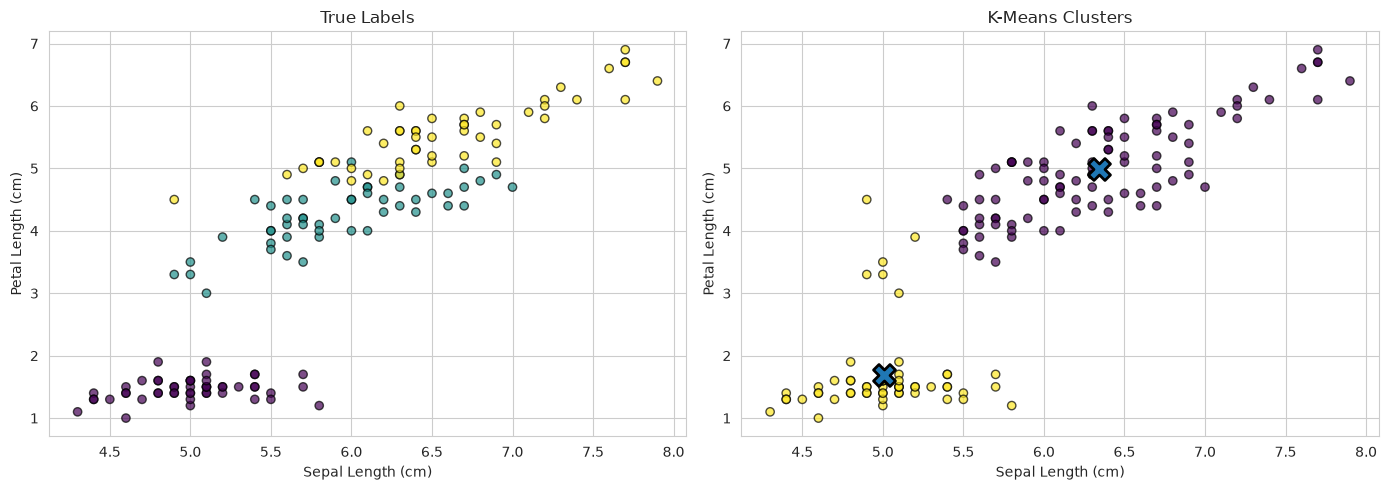

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True labels
axes[0].scatter(
    X_iris[:, 0],
    X_iris[:, 1],
    c=y_iris,
    cmap="viridis",
    alpha=0.7,
    edgecolors="k"
)

axes[0].set_xlabel("Sepal Length (cm)")
axes[0].set_ylabel("Petal Length (cm)")
axes[0].set_title("True Labels")

# K-Means
axes[1].scatter(
    X_iris[:, 0],
    X_iris[:, 1],
    c=iris_clusters,
    cmap="viridis",
    alpha=0.7,
    edgecolors="k"
)

axes[1].scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker="X",
    s=250,
    edgecolors="black",
    linewidths=2
)

axes[1].set_xlabel("Sepal Length (cm)")
axes[1].set_ylabel("Petal Length (cm)")
axes[1].set_title("K-Means Clusters")

plt.tight_layout()
plt.show()

In [13]:
# Menambahkan hasil cluster ke dataframe
iris_clustered = iris_df.copy()
iris_clustered["Cluster"] = iris_clusters

print("=== Jumlah Data Setiap Cluster ===")
print(
    iris_clustered["Cluster"].value_counts().sort_index()
)

print("\n=== Rata-rata Fitur Setiap Cluster ===")
display(
    iris_clustered.groupby("Cluster")[
        ["sepal length (cm)", "petal length (cm)"]
    ].mean()
)

=== Jumlah Data Setiap Cluster ===
Cluster
0    94
1    56
Name: count, dtype: int64

=== Rata-rata Fitur Setiap Cluster ===


,sepal length (cm),petal length (cm)
Cluster,,
0,6.341489,4.990426
1,5.007143,1.689286


## Interpretasi Tugas 1

K-Means berhasil membagi dataset Iris menjadi beberapa cluster berdasarkan kemiripan karakteristik fitur.

Hasil clustering dapat dibandingkan dengan true labels untuk melihat apakah cluster yang terbentuk memiliki pola yang mirip dengan kelas asli.

Iris setosa biasanya lebih mudah dipisahkan karena ukuran sepal dan petal berbeda cukup jelas. Sementara itu, Iris versicolor dan Iris virginica memiliki karakteristik yang lebih mirip sehingga sebagian data dapat berada pada cluster yang sama atau berdekatan.

Silhouette Score digunakan untuk melihat kualitas pemisahan cluster. Semakin tinggi nilainya, semakin baik pemisahan antar-cluster.

Secara keseluruhan, K-Means cukup berhasil menemukan struktur alami pada dataset Iris, walaupun hasil cluster tidak harus sama persis dengan label asli karena K-Means merupakan metode unsupervised learning dan tidak menggunakan label saat proses clustering.

Jumlah data: 100
Jumlah fitur: 2


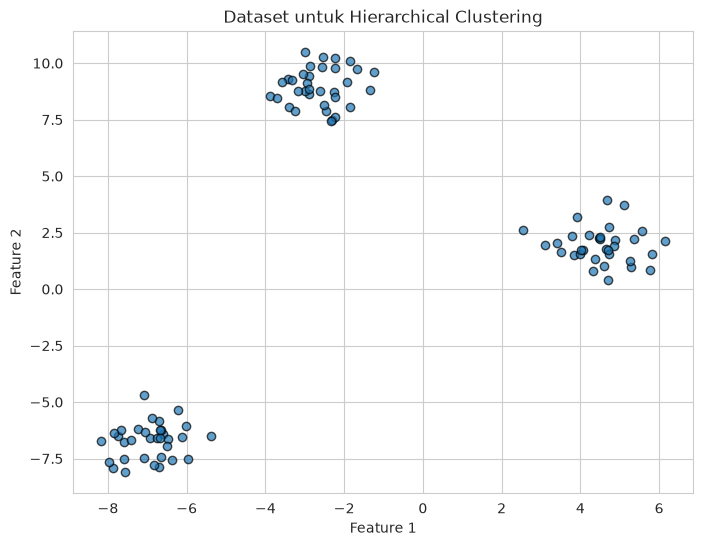

In [14]:
# ============================================
# TUGAS 2 - HIERARCHICAL CLUSTERING
# ============================================

X_hier, _ = make_blobs(
    n_samples=100,
    centers=3,
    n_features=2,
    cluster_std=0.8,
    random_state=42
)

print("Jumlah data:", X_hier.shape[0])
print("Jumlah fitur:", X_hier.shape[1])

plt.figure(figsize=(8, 6))
plt.scatter(
    X_hier[:, 0],
    X_hier[:, 1],
    alpha=0.7,
    edgecolors="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset untuk Hierarchical Clustering")
plt.show()

In [15]:
# ============================================
# LINKAGE METHODS
# ============================================

linkage_methods = [
    "single",
    "complete",
    "average",
    "ward"
]

linkage_matrices = {}

for method in linkage_methods:
    linkage_matrices[method] = linkage(
        X_hier,
        method=method
    )

print("Linkage matrix berhasil dibuat untuk:")
for method in linkage_methods:
    print("-", method)

Linkage matrix berhasil dibuat untuk:
- single
- complete
- average
- ward


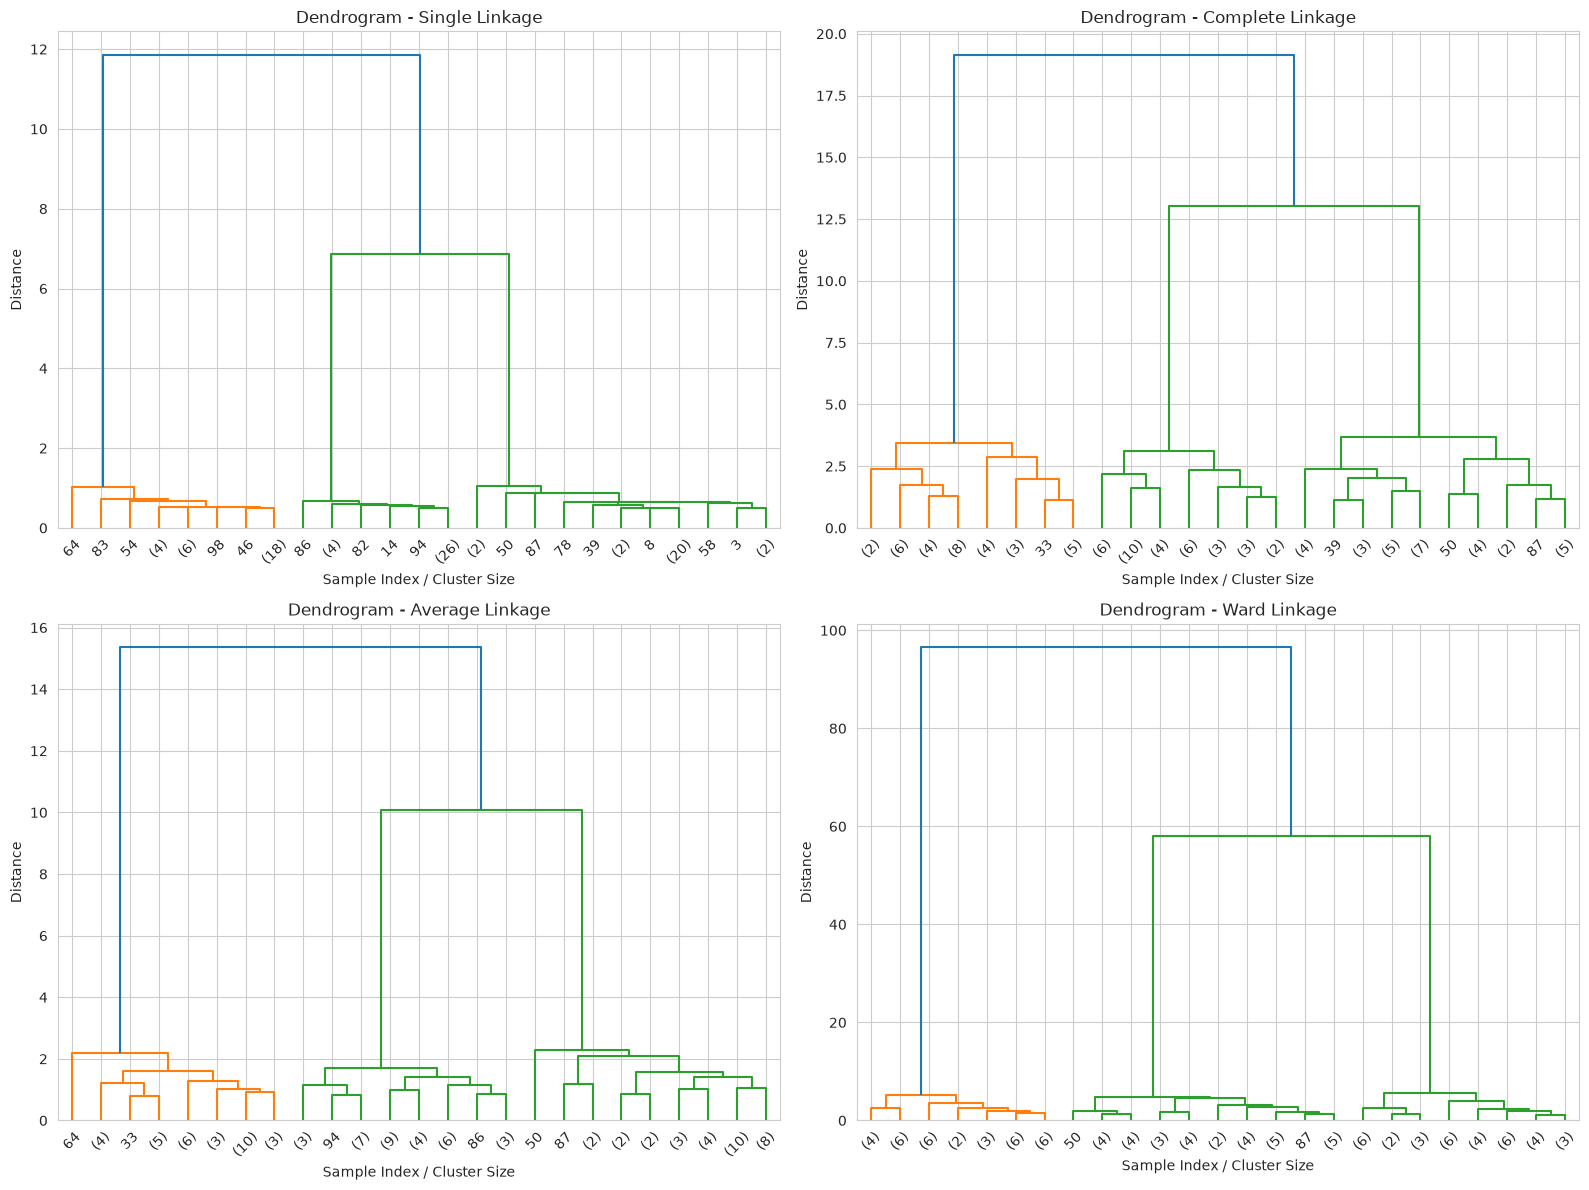

In [16]:
# ============================================
# DENDROGRAM
# ============================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 12)
)

for idx, method in enumerate(linkage_methods):
    row = idx // 2
    col = idx % 2

    dendrogram(
        linkage_matrices[method],
        truncate_mode="lastp",
        p=25,
        show_leaf_counts=True,
        ax=axes[row, col]
    )

    axes[row, col].set_title(
        f"Dendrogram - {method.capitalize()} Linkage"
    )
    axes[row, col].set_xlabel(
        "Sample Index / Cluster Size"
    )
    axes[row, col].set_ylabel("Distance")

plt.tight_layout()
plt.show()

In [17]:
# ============================================
# PERBANDINGAN LINKAGE
# ============================================

hier_results = []

for method in linkage_methods:
    agg = AgglomerativeClustering(
        n_clusters=3,
        linkage=method
    )

    labels = agg.fit_predict(X_hier)

    sil = silhouette_score(
        X_hier,
        labels
    )

    db = davies_bouldin_score(
        X_hier,
        labels
    )

    hier_results.append({
        "Linkage": method,
        "Silhouette Score": sil,
        "Davies-Bouldin Index": db
    })

hier_results_df = pd.DataFrame(hier_results)

print("=== Perbandingan Linkage Methods ===")
display(hier_results_df)

=== Perbandingan Linkage Methods ===


,Linkage,Silhouette Score,Davies-Bouldin Index
0,single,0.877807,0.170832
1,complete,0.877807,0.170832
2,average,0.877807,0.170832
3,ward,0.877807,0.170832


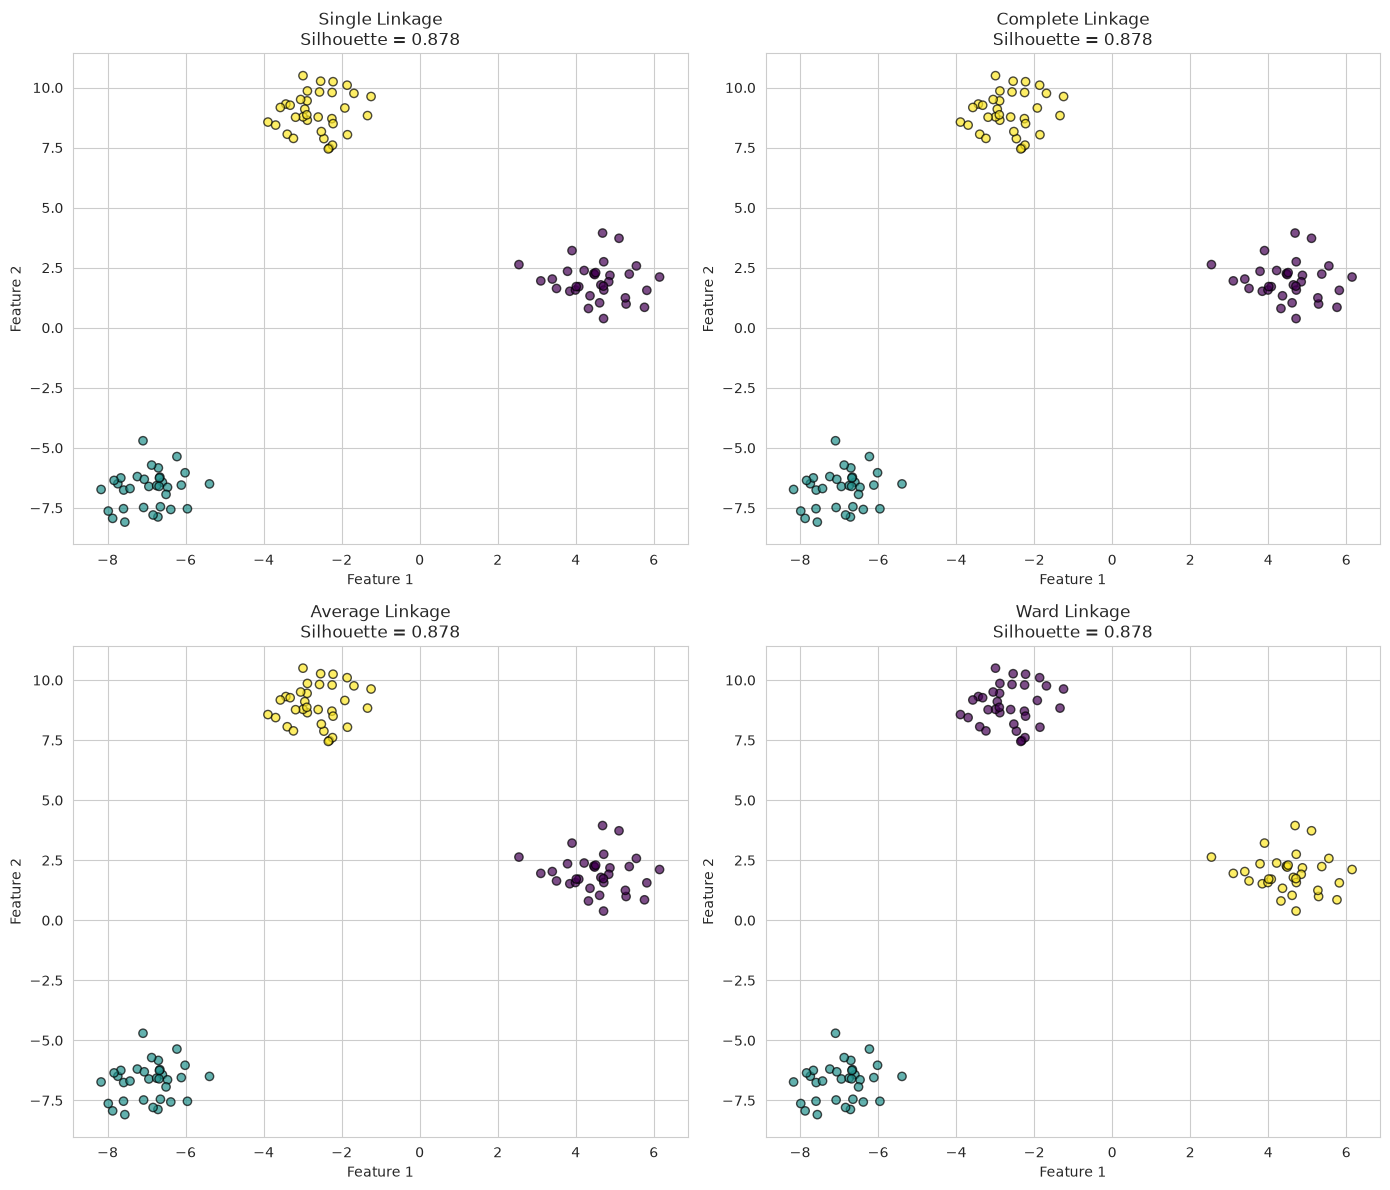

In [18]:
# ============================================
# VISUALISASI HASIL CLUSTERING
# ============================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 12)
)

for idx, method in enumerate(linkage_methods):
    row = idx // 2
    col = idx % 2

    agg = AgglomerativeClustering(
        n_clusters=3,
        linkage=method
    )

    labels = agg.fit_predict(X_hier)

    sil = silhouette_score(
        X_hier,
        labels
    )

    axes[row, col].scatter(
        X_hier[:, 0],
        X_hier[:, 1],
        c=labels,
        cmap="viridis",
        alpha=0.7,
        edgecolors="k"
    )

    axes[row, col].set_xlabel("Feature 1")
    axes[row, col].set_ylabel("Feature 2")
    axes[row, col].set_title(
        f"{method.capitalize()} Linkage\n"
        f"Silhouette = {sil:.3f}"
    )

plt.tight_layout()
plt.show()

In [19]:
# ============================================
# ANALISIS LINKAGE TERBAIK
# ============================================

best_linkage = hier_results_df.loc[
    hier_results_df["Silhouette Score"].idxmax(),
    "Linkage"
]

print("=== Linkage Terbaik ===")
print("Linkage:", best_linkage)
print(
    "Silhouette Score:",
    hier_results_df["Silhouette Score"].max()
)
print(
    "Davies-Bouldin Index:",
    hier_results_df["Davies-Bouldin Index"].min()
)

print("\nCatatan:")
print(
    "Pada dataset ini semua linkage menghasilkan "
    "nilai evaluasi yang sama."
)

=== Linkage Terbaik ===
Linkage: single
Silhouette Score: 0.8778074939705753
Davies-Bouldin Index: 0.17083248702732656

Catatan:
Pada dataset ini semua linkage menghasilkan nilai evaluasi yang sama.


In [20]:
# ============================================
# TEST BERBAGAI JUMLAH CLUSTER
# ============================================

cluster_range = range(2, 7)

cluster_results = []

for n in cluster_range:
    agg = AgglomerativeClustering(
        n_clusters=n,
        linkage="ward"
    )

    labels = agg.fit_predict(X_hier)

    cluster_results.append({
        "n_clusters": n,
        "Silhouette Score": silhouette_score(
            X_hier, labels
        ),
        "Davies-Bouldin Index": davies_bouldin_score(
            X_hier, labels
        )
    })

cluster_results_df = pd.DataFrame(cluster_results)

print("=== Perbandingan Jumlah Cluster ===")
display(cluster_results_df)

=== Perbandingan Jumlah Cluster ===


,n_clusters,Silhouette Score,Davies-Bouldin Index
0,2,0.717958,0.411506
1,3,0.877807,0.170832
2,4,0.716194,0.549653
3,5,0.547077,0.786929
4,6,0.348084,0.992063


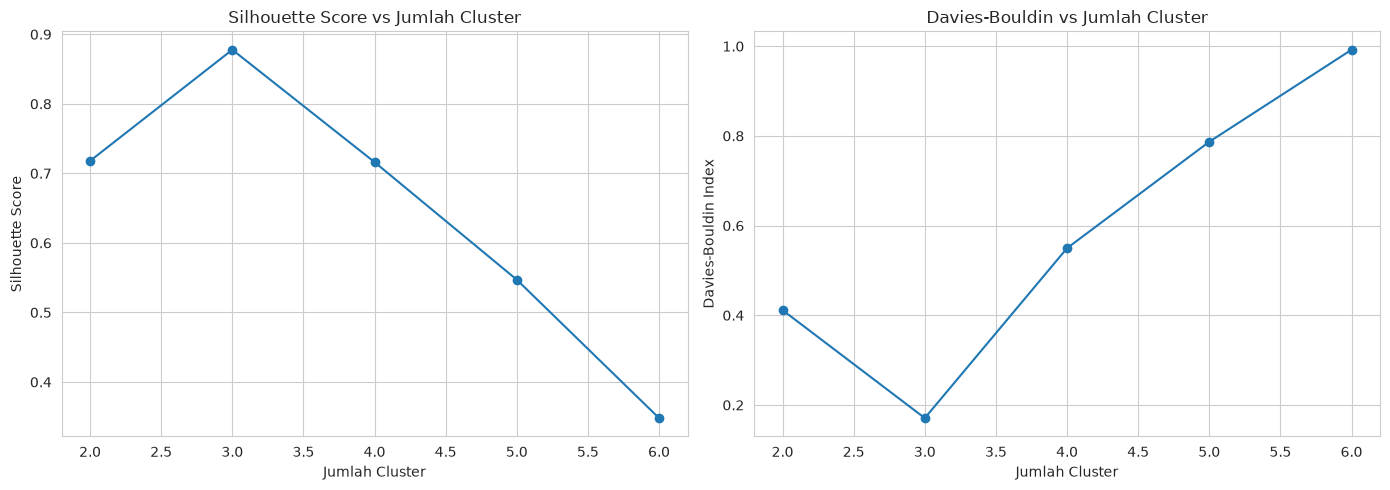

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    cluster_results_df["n_clusters"],
    cluster_results_df["Silhouette Score"],
    marker="o"
)

axes[0].set_xlabel("Jumlah Cluster")
axes[0].set_ylabel("Silhouette Score")
axes[0].set_title("Silhouette Score vs Jumlah Cluster")
axes[0].grid(True)

axes[1].plot(
    cluster_results_df["n_clusters"],
    cluster_results_df["Davies-Bouldin Index"],
    marker="o"
)

axes[1].set_xlabel("Jumlah Cluster")
axes[1].set_ylabel("Davies-Bouldin Index")
axes[1].set_title("Davies-Bouldin vs Jumlah Cluster")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [22]:
# ============================================
# HIERARCHICAL CLUSTERING FINAL
# ============================================

best_n_clusters = cluster_results_df.loc[
    cluster_results_df["Silhouette Score"].idxmax(),
    "n_clusters"
]

agg_final = AgglomerativeClustering(
    n_clusters=int(best_n_clusters),
    linkage="ward"
)

hier_labels_final = agg_final.fit_predict(X_hier)

print("=== HASIL FINAL ===")
print("Jumlah cluster:", best_n_clusters)
print(
    "Silhouette Score:",
    f"{silhouette_score(X_hier, hier_labels_final):.4f}"
)
print(
    "Davies-Bouldin Index:",
    f"{davies_bouldin_score(X_hier, hier_labels_final):.4f}"
)

=== HASIL FINAL ===
Jumlah cluster: 3
Silhouette Score: 0.8778
Davies-Bouldin Index: 0.1708


## Kesimpulan Tugas 2

Hierarchical Clustering berhasil mengelompokkan data menjadi beberapa cluster menggunakan metode Agglomerative Clustering.

Empat metode linkage yang dibandingkan adalah Single, Complete, Average, dan Ward. Pada dataset yang digunakan, keempat metode menghasilkan nilai Silhouette Score dan Davies-Bouldin Index yang sama.

Jumlah cluster kemudian dibandingkan menggunakan Silhouette Score dan Davies-Bouldin Index. Silhouette Score yang lebih tinggi menunjukkan cluster yang lebih baik, sedangkan Davies-Bouldin Index yang lebih rendah menunjukkan pemisahan cluster yang lebih baik.

Dendrogram membantu melihat proses penggabungan data dari cluster kecil menjadi cluster yang lebih besar. Secara keseluruhan, Hierarchical Clustering dapat digunakan untuk melihat struktur hubungan antar-data secara bertahap.

In [23]:
# ============================================================
# TUGAS 3 — PERBANDINGAN K-MEANS VS HIERARCHICAL
# ============================================================

import time
from sklearn.datasets import make_blobs

# Membuat dataset clustering sintetis
X_compare_raw, y_compare_true = make_blobs(
    n_samples=500,
    centers=4,
    n_features=2,
    cluster_std=1.0,
    random_state=42
)

# Standardisasi
scaler_compare = StandardScaler()
X_compare_scaled = scaler_compare.fit_transform(X_compare_raw)

print("Jumlah data:", X_compare_scaled.shape[0])
print("Jumlah fitur:", X_compare_scaled.shape[1])
print("Jumlah cluster sebenarnya:", len(np.unique(y_compare_true)))

Jumlah data: 500
Jumlah fitur: 2
Jumlah cluster sebenarnya: 4


In [24]:
# Menentukan jumlah cluster
k_compare = 4

# -------------------------
# K-MEANS
# -------------------------
start_kmeans = time.perf_counter()

kmeans_compare = KMeans(
    n_clusters=k_compare,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans_compare.fit_predict(X_compare_scaled)

time_kmeans = time.perf_counter() - start_kmeans


# -------------------------
# HIERARCHICAL
# -------------------------
start_hier = time.perf_counter()

hier_compare = AgglomerativeClustering(
    n_clusters=k_compare,
    linkage="ward"
)

labels_hier = hier_compare.fit_predict(X_compare_scaled)

time_hier = time.perf_counter() - start_hier

print("K-Means selesai.")
print("Hierarchical selesai.")

K-Means selesai.
Hierarchical selesai.


In [25]:
# Menghitung metrik evaluasi

sil_kmeans = silhouette_score(X_compare_scaled, labels_kmeans)
db_kmeans = davies_bouldin_score(X_compare_scaled, labels_kmeans)

sil_hier = silhouette_score(X_compare_scaled, labels_hier)
db_hier = davies_bouldin_score(X_compare_scaled, labels_hier)

hasil_perbandingan = pd.DataFrame({
    "Metode": ["K-Means", "Hierarchical"],
    "Silhouette Score": [sil_kmeans, sil_hier],
    "Davies-Bouldin Index": [db_kmeans, db_hier],
    "Waktu (detik)": [time_kmeans, time_hier]
})

print("=== HASIL PERBANDINGAN ===")
display(hasil_perbandingan)

=== HASIL PERBANDINGAN ===


,Metode,Silhouette Score,Davies-Bouldin Index,Waktu (detik)
0,K-Means,0.797919,0.281928,0.016459
1,Hierarchical,0.797919,0.281928,0.006994


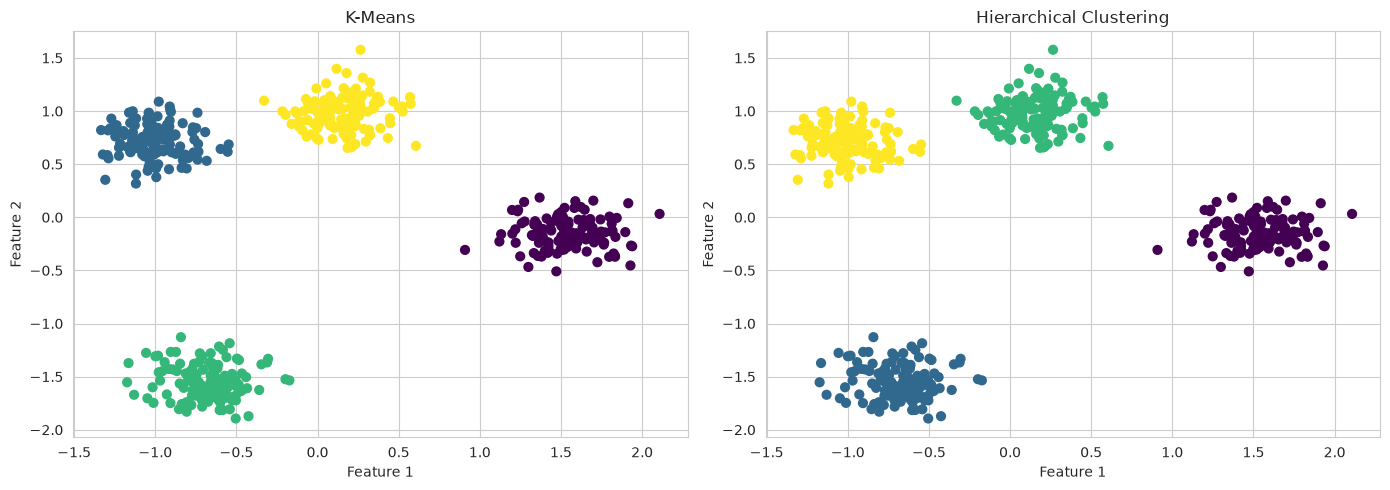

In [26]:
# Visualisasi hasil clustering

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    X_compare_scaled[:, 0],
    X_compare_scaled[:, 1],
    c=labels_kmeans,
    cmap="viridis",
    s=40
)
axes[0].set_title("K-Means")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(
    X_compare_scaled[:, 0],
    X_compare_scaled[:, 1],
    c=labels_hier,
    cmap="viridis",
    s=40
)
axes[1].set_title("Hierarchical Clustering")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

## Kesimpulan Tugas 3

Berdasarkan hasil perbandingan, K-Means dan Hierarchical Clustering dapat digunakan untuk
mengelompokkan data menjadi 4 cluster. Perbandingan dilakukan menggunakan Silhouette Score,
Davies-Bouldin Index, dan waktu komputasi.

Silhouette Score yang lebih tinggi menunjukkan cluster yang lebih baik, sedangkan
Davies-Bouldin Index yang lebih rendah menunjukkan cluster yang lebih baik.

K-Means memiliki kelebihan berupa proses yang cepat dan sederhana sehingga cocok untuk
dataset berukuran besar. Kekurangannya adalah jumlah cluster harus ditentukan terlebih dahulu.

Hierarchical Clustering memiliki kelebihan karena dapat menunjukkan struktur hubungan antar
data melalui dendrogram dan tidak terlalu bergantung pada inisialisasi centroid. Kekurangannya
adalah prosesnya dapat lebih berat ketika jumlah data semakin besar.

Pada dataset ini, metode dengan nilai evaluasi yang lebih baik dapat dipilih sebagai metode
clustering yang paling sesuai.

In [28]:
# ============================================================
# TUGAS 4 — CUSTOMER SEGMENTATION
# ============================================================

# Membuat dataset customer sintetis
np.random.seed(42)

n_customers = 500

customer_data = pd.DataFrame({
    "Age": np.random.randint(18, 61, n_customers),
    "Annual_Income": np.random.randint(20, 121, n_customers),
    "Spending_Score": np.random.randint(1, 101, n_customers),
    "Purchase_Frequency": np.random.randint(1, 31, n_customers)
})

print("Jumlah customer:", len(customer_data))
print("\n5 data pertama:")
display(customer_data.head())

print("\nInformasi dataset:")
display(customer_data.describe())

Jumlah customer: 500

5 data pertama:


,Age,Annual_Income,Spending_Score,Purchase_Frequency
0,56,101,2,23
1,46,115,84,29
2,32,43,65,18
3,60,42,63,30
4,25,81,73,20



Informasi dataset:


,Age,Annual_Income,Spending_Score,Purchase_Frequency
count,500.000000,500.000000,500.00000,500.00000
mean,39.506000,69.012000,49.51000,15.83000
std,12.368505,30.102628,28.64715,8.85901
min,18.000000,20.000000,1.00000,1.00000
25%,29.000000,42.000000,26.00000,8.00000
50%,41.000000,70.000000,49.00000,15.00000
75%,50.000000,95.000000,73.25000,24.00000
max,60.000000,120.000000,100.00000,30.00000


=== Missing Value ===
Age                   0
Annual_Income         0
Spending_Score        0
Purchase_Frequency    0
dtype: int64

=== Statistik Deskriptif ===


,Age,Annual_Income,Spending_Score,Purchase_Frequency
count,500.000000,500.000000,500.00000,500.00000
mean,39.506000,69.012000,49.51000,15.83000
std,12.368505,30.102628,28.64715,8.85901
min,18.000000,20.000000,1.00000,1.00000
25%,29.000000,42.000000,26.00000,8.00000
50%,41.000000,70.000000,49.00000,15.00000
75%,50.000000,95.000000,73.25000,24.00000
max,60.000000,120.000000,100.00000,30.00000


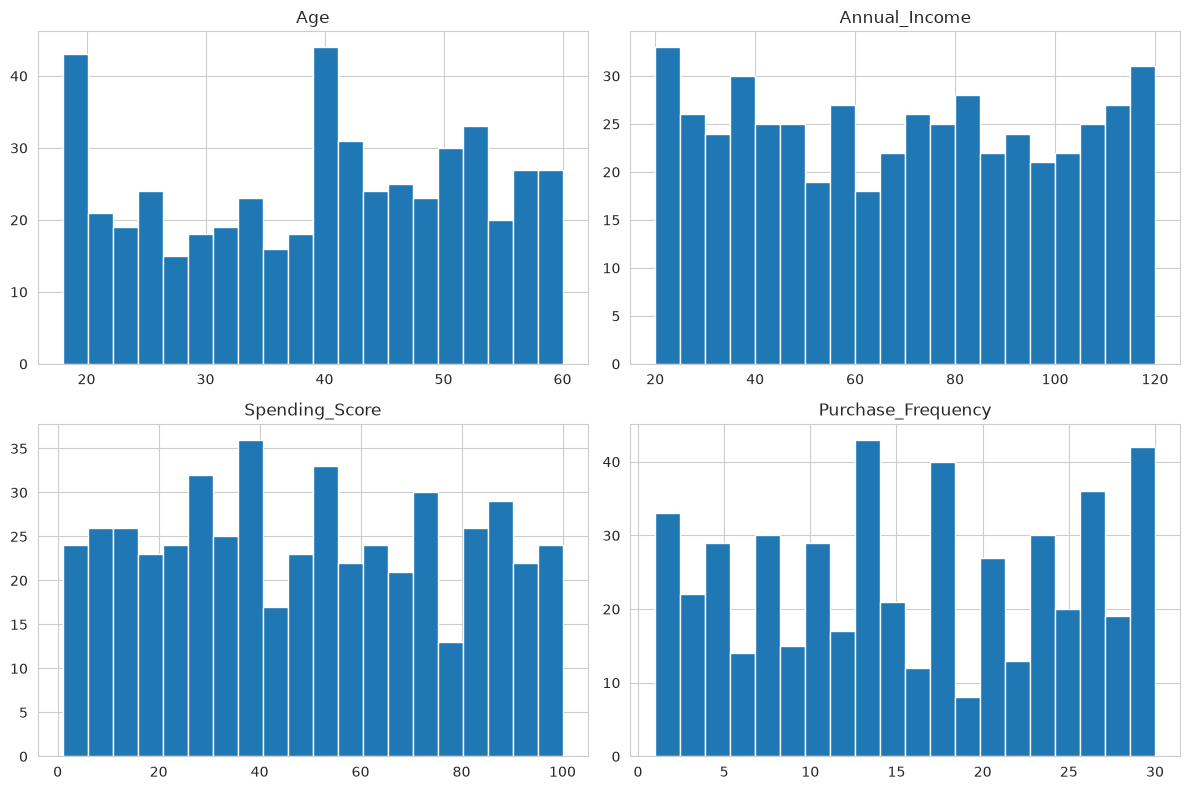

In [29]:
# Mengecek missing value dan statistik dataset

print("=== Missing Value ===")
print(customer_data.isnull().sum())

print("\n=== Statistik Deskriptif ===")
display(customer_data.describe())

# Visualisasi distribusi fitur
customer_data.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

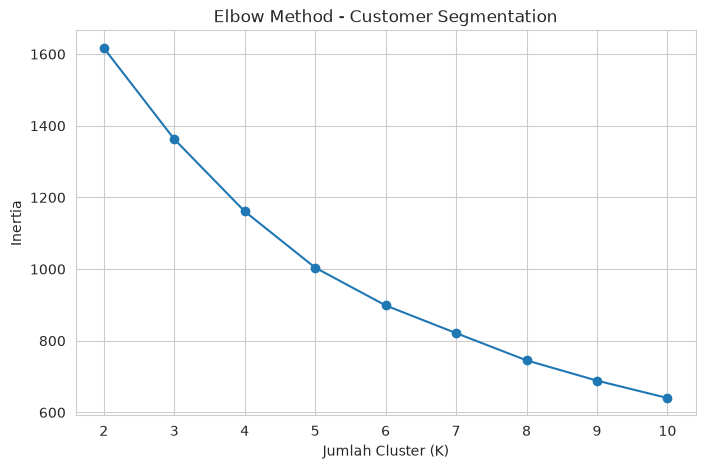

In [30]:
# Memilih fitur untuk segmentasi
features_customer = [
    "Age",
    "Annual_Income",
    "Spending_Score",
    "Purchase_Frequency"
]

X_customer = customer_data[features_customer]

# Standardisasi
scaler_customer = StandardScaler()
X_customer_scaled = scaler_customer.fit_transform(X_customer)

# Mencari jumlah cluster optimal dengan Elbow
inertias_customer = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_customer_scaled)
    inertias_customer.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertias_customer, marker="o")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Customer Segmentation")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [31]:
# Menggunakan K = 4 sebagai jumlah cluster
optimal_k_customer = 4

kmeans_customer = KMeans(
    n_clusters=optimal_k_customer,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans_customer.fit_predict(X_customer_scaled)

print("Jumlah customer setiap cluster:")
print(customer_data["Cluster"].value_counts().sort_index())

print("\n=== Profil Setiap Cluster ===")

cluster_profile = customer_data.groupby("Cluster")[
    features_customer
].mean().round(2)

display(cluster_profile)

Jumlah customer setiap cluster:
Cluster
0    128
1    127
2    136
3    109
Name: count, dtype: int64

=== Profil Setiap Cluster ===


,Age,Annual_Income,Spending_Score,Purchase_Frequency
Cluster,,,,
0,26.70,77.75,32.57,21.05
1,37.99,43.06,52.42,7.82
2,46.25,98.76,54.81,11.80
3,47.90,51.88,59.40,24.06


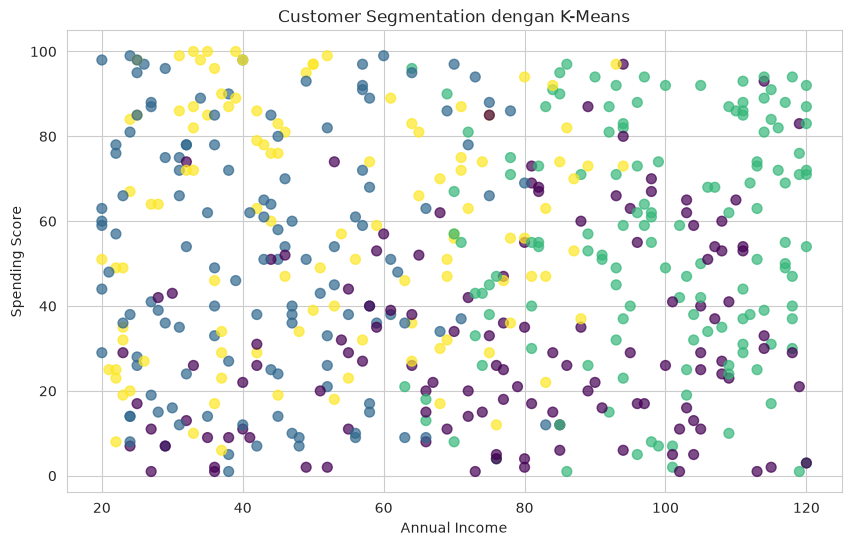

Silhouette Score: 0.2057
Davies-Bouldin Index: 1.4135


In [32]:
# Visualisasi segmentasi berdasarkan pendapatan dan spending score

plt.figure(figsize=(10, 6))

plt.scatter(
    customer_data["Annual_Income"],
    customer_data["Spending_Score"],
    c=customer_data["Cluster"],
    cmap="viridis",
    s=50,
    alpha=0.7
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation dengan K-Means")
plt.grid(True)
plt.show()

print("Silhouette Score:",
      round(silhouette_score(X_customer_scaled, customer_data["Cluster"]), 4))

print("Davies-Bouldin Index:",
      round(davies_bouldin_score(X_customer_scaled, customer_data["Cluster"]), 4))

## Rekomendasi Bisnis Customer Segmentation

Berdasarkan hasil clustering, customer terbagi menjadi beberapa segmen berdasarkan
usia, pendapatan tahunan, spending score, dan frekuensi pembelian.

Customer dengan spending score dan frekuensi pembelian yang tinggi dapat diberikan
program loyalitas, diskon khusus, dan penawaran produk premium.

Customer dengan pendapatan tinggi tetapi spending score rendah dapat diberikan
promosi atau rekomendasi produk yang lebih sesuai untuk meningkatkan pembelian.

Customer dengan spending score rendah dan frekuensi pembelian rendah dapat diberikan
promo perkenalan, voucher, atau diskon untuk menarik minat pembelian.

Customer dengan aktivitas pembelian sedang dapat diberikan rekomendasi produk dan
program promosi untuk meningkatkan frekuensi pembelian.

## Kesimpulan Tugas 4

Customer segmentation berhasil dilakukan menggunakan metode K-Means.

Data customer terlebih dahulu diperiksa dan distandarisasi agar setiap fitur memiliki
skala yang seimbang. Jumlah cluster terbaik ditentukan menggunakan Silhouette Score.

Hasil clustering menghasilkan beberapa kelompok customer dengan karakteristik yang
berbeda berdasarkan usia, pendapatan, spending score, dan frekuensi pembelian.

Segmentasi ini dapat membantu bisnis menentukan strategi pemasaran yang berbeda untuk
setiap kelompok customer, seperti pemberian diskon, program loyalitas, rekomendasi
produk, dan promosi khusus.

Dengan menggunakan clustering, perusahaan dapat memahami karakteristik customer
dengan lebih mudah dan membuat strategi pemasaran yang lebih sesuai.

# Kesimpulan Pertemuan 7

Pada praktikum ini telah dipelajari metode clustering menggunakan K-Means dan
Hierarchical Clustering.

K-Means digunakan untuk mengelompokkan data berdasarkan kedekatan dengan centroid,
sedangkan Hierarchical Clustering digunakan untuk melihat hubungan antar data dalam
bentuk struktur hierarki.

Penentuan jumlah cluster dilakukan menggunakan Elbow Method dan Silhouette Score.
Pada dataset Iris, jumlah cluster yang paling optimal adalah 3 cluster.

Hasil perbandingan K-Means dan Hierarchical menunjukkan bahwa kedua metode dapat
menghasilkan cluster yang baik. Pemilihan metode dapat disesuaikan dengan ukuran data
dan kebutuhan analisis.

Pada customer segmentation, K-Means digunakan untuk membagi customer berdasarkan
usia, pendapatan, spending score, dan frekuensi pembelian. Hasil segmentasi dapat
digunakan untuk membantu menentukan strategi pemasaran yang berbeda untuk setiap
kelompok customer.

Secara keseluruhan, clustering dapat membantu menemukan pola dan kelompok dalam data
tanpa membutuhkan label atau target sebelumnya.

## Checklist Pertemuan 7

- [x] Memahami konsep unsupervised learning
- [x] Memahami K-Means Clustering
- [x] Menggunakan Elbow Method
- [x] Menggunakan Silhouette Score
- [x] Menggunakan Davies-Bouldin Index
- [x] Memahami Hierarchical Clustering
- [x] Membuat dendrogram
- [x] Membandingkan linkage
- [x] Membandingkan K-Means dan Hierarchical
- [x] Melakukan customer segmentation
- [x] Membuat profil customer
- [x] Membuat rekomendasi bisnis
- [x] Membuat kesimpulan praktikum

---

**Nama:** MUH. ALI IMRAN  
**NIM:** 105841113523  
**Program Studi:** Informatika  
**Mata Kuliah:** Applied Machine Learning  

**Pertemuan 7 — K-Means Clustering dan Hierarchical Clustering**